# ChatGLM3-6B QLoRA 指令微调全流程

## 真实案例：CS 编程知识问答领域微调

**业务场景**：基座模型能回答通用编程问题，但对特定领域术语（如 DeepSpeed ZeRO、LoRA 原理）的回答不够精确，
格式也不规范（缺少代码示例、解释结构混乱）。通过微调，让模型更专业、更结构化地输出。

**适用平台**：AutoDL 云 GPU（Linux），推荐 A4000 / 3090 / 4090 单卡

## 0. 环境安装

In [2]:
# 首次运行取消注释下面几行来安装依赖
# !pip install torch transformers peft trl datasets accelerate bitsandbytes scipy -i https://pypi.tuna.tsinghua.edu.cn/simple
# !pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple

In [1]:
import os
import json
import re
import hashlib
import random
import torch
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Optional
from dataclasses import dataclass

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    #print(f'VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')

PyTorch: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 4090 D


## 1. 准备训练数据（三种方式）

### 数据来源 A：mixed 混搭数据集（`DATA_SOURCE = "mixed"`，当前默认）
从 `mixed_6000.json` 或 `mixed_12000.json` 加载。包含 1122 条 AI 概念问答（Agent Skills / Tool Use / MCP 等，3x 重复增强）+ Alpaca 通用问答填充。AI 数据使用专家级 system prompt，Alpaca 使用简单 prompt。

### 数据来源 B：full_dataset.json（`DATA_SOURCE = "json"`）
2000 条混合数据集：1415 Alpaca 通用 + 316 生成 + 269 原始 AI 概念问答。text 字段已是 ChatML 格式。

### 数据来源 C：Alpaca 中文数据集（`DATA_SOURCE = "alpaca"`）
从 `/dataset/alpaca-data-gpt4-chinese/Alpaca_data_gpt4_zh.json`（52K 条）随机抽取，条数由 `ALPACA_SAMPLES` 控制。纯通用问答，用于验证微调 pipeline 本身是否有效。

### 如何切换
修改 Cell 5 中的 `DATA_SOURCE` 变量即可。


In [2]:
# ============================================================
# 数据来源选择 —— 修改下面这个变量即可切换
# ============================================================
# "mixed"  → mixed_6000.json / mixed_12000.json（Alpaca + AI 概念混搭）
# "json"   → full_dataset.json（2000 条混合数据集）
# "alpaca" → Alpaca_data_gpt4_zh.json（纯通用问答，条数由 ALPACA_SAMPLES 控制）
DATA_SOURCE = "mixed"
MIXED_SIZE = 12000         # 仅 mixed 模式：6000 或 12000
ALPACA_SAMPLES = 6000     # 仅 alpaca 模式：通用问答条数
AI_DUP_TIMES = 3           # AI 数据重复倍数（让模型多看几遍）

# 推理时使用的 System Prompt
if DATA_SOURCE == "mixed" or DATA_SOURCE == "json":
    SYSTEM_PROMPT = (
        "你是一个专业的AI技术专家，擅长回答人工智能、大语言模型、Agent系统、提示词工程、"
        "工具调用、推理部署等前沿技术概念。请用清晰、准确、有条理的中文回答问题，"
        "需要时提供技术对比表格、代码示例或架构图描述。"
    )
else:
    SYSTEM_PROMPT = "你是一个有帮助的AI助手。"

# ============================================================
# 数据来源 A：mixed 混搭数据集（Alpaca 通用 + AI 概念问答）
# ============================================================
if DATA_SOURCE == "mixed":
    MIXED_PATH = f"./mixed_{MIXED_SIZE}.json"
    
    if not os.path.exists(MIXED_PATH):
        alt = f"/root/autodl-tmp/finetune/mixed_{MIXED_SIZE}.json"
        MIXED_PATH = alt if os.path.exists(alt) else MIXED_PATH
    
    if not os.path.exists(MIXED_PATH):
        raise FileNotFoundError(f"Mixed 数据集未找到: {MIXED_PATH}。请先运行 build_mixed_dataset.py 生成。")
    
    with open(MIXED_PATH, 'r', encoding='utf-8') as f:
        mixed_data = json.load(f)
    
    raw_training_data = []
    for item in mixed_data:
        raw_training_data.append({
            'instruction': item['instruction'],
            'response': item['response'],
            'text': item['text'],
            'topic': item.get('topic', ''),
            'source': item.get('source', ''),
        })
    
    from collections import Counter
    src_counts = Counter(item['source'] for item in raw_training_data)
    ai_topics = Counter(item['topic'] for item in raw_training_data if item['source'] == 'AI-Concepts')
    
    print(f"从 {MIXED_PATH} 加载: {len(raw_training_data)} 条")
    print(f"\n来源分布:")
    for src, cnt in src_counts.most_common():
        print(f"  [{cnt:5d}] {src}")
    print(f"\nAI 话题分布 (Top 12):")
    for topic, cnt in ai_topics.most_common(12):
        print(f"  [{cnt:4d}] {topic}")

# ============================================================
# 数据来源 B：full_dataset.json（2000 条混合）
# ============================================================
elif DATA_SOURCE == "json":
    JSON_PATH = "./full_dataset.json"
    
    if not os.path.exists(JSON_PATH):
        alt = "/root/autodl-tmp/finetune/full_dataset.json"
        JSON_PATH = alt if os.path.exists(alt) else JSON_PATH
    
    if not os.path.exists(JSON_PATH):
        raise FileNotFoundError(f"JSON 文件未找到: {JSON_PATH}")
    
    with open(JSON_PATH, 'r', encoding='utf-8') as f:
        json_data = json.load(f)
    
    raw_training_data = []
    skipped = 0
    for item in json_data:
        inst = item.get('instruction', '').strip()
        resp = item.get('response', '').strip()
        text = item.get('text', '').strip()
        if not inst or not resp or not text:
            skipped += 1
            continue
        raw_training_data.append({
            'instruction': inst,
            'response': resp,
            'text': text,
            'topic': item.get('topic', ''),
            'source': item.get('source', ''),
        })
    
    from collections import Counter
    source_counts = Counter(item['source'] for item in raw_training_data)
    topic_counts = Counter(item['topic'] for item in raw_training_data)
    
    print(f"从 full_dataset.json 加载: {len(raw_training_data)} 条 ({skipped} 条跳过)")
    print(f"\n来源分布:")
    for src, cnt in source_counts.most_common():
        print(f"  [{cnt:4d}] {src}")
    print(f"\n话题分布 (Top 15):")
    for topic, cnt in topic_counts.most_common(15):
        print(f"  [{cnt:4d}] {topic}")

# ============================================================
# 数据来源 C：Alpaca 中文数据集（纯通用问答）
# ============================================================
else:
    ALPACA_PATH = "/root/autodl-tmp/dataset/alpaca-data-gpt4-chinese/Alpaca_data_gpt4_zh.json"
    
    if not os.path.exists(ALPACA_PATH):
        raise FileNotFoundError(f"Alpaca 数据集未找到: {ALPACA_PATH}")
    
    with open(ALPACA_PATH, 'r', encoding='utf-8') as f:
        alpaca_data = json.load(f)
    
    random.seed(42)
    sampled = random.sample(alpaca_data, min(ALPACA_SAMPLES, len(alpaca_data)))
    
    raw_training_data = []
    for item in sampled:
        inst = item.get('instruction', '').strip()
        resp = item.get('response', '').strip()
        if not inst or not resp:
            continue
        text = (
            f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
            f"<|im_start|>user\n{inst}<|im_end|>\n"
            f"<|im_start|>assistant\n{resp}<|im_end|>"
        )
        raw_training_data.append({
            'instruction': inst,
            'response': resp,
            'text': text,
            'topic': 'general',
            'source': 'Alpaca',
        })
    
    print(f"从 Alpaca 数据集加载: {len(raw_training_data)} 条（随机抽取自 {len(alpaca_data)} 条）")

print(f"\n最终数据总量: {len(raw_training_data)} 条")



从 ./mixed_12000.json 加载: 12000 条

来源分布:
  [10878] Alpaca
  [ 1122] AI-Concepts

AI 话题分布 (Top 12):
  [ 117] Agent Skills（智能体技能）
  [  99] Prompt Caching（提示词缓存）
  [  87] Tool Use（工具调用）
  [  72] Claude Agent SDK
  [  72] MCP（模型上下文协议）
  [  72] Compaction（上下文压缩）
  [  66] Extended Thinking（扩展思考）
  [  63] Building Effective Agents（构建高效智能体）
  [  63] Prompt Engineering（提示词工程）
  [  60] Context Windows（上下文窗口）
  [  57] Context Engineering & Harness Engineering（上下文工程与框架工程）
  [  51] Agent Safety（智能体安全）

最终数据总量: 12000 条


## 2. 数据清洗（含注释说明每一步的目的）

In [3]:
def clean_text(text: str) -> str:
    """
    基础文本清洗。
    注意：对于技术文本，保留代码块（```）和缩进，只去除真正的脏数据。
    """
    if not text or not text.strip():
        return ""
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    text = re.sub(r'\n{3,}', '\n\n', text)
    lines = [line.strip() for line in text.split('\n')]
    text = '\n'.join(lines)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()


def filter_by_quality(data: List[Dict]) -> List[Dict]:
    """质量筛选：去除空值、过短回复、纯寒暄等低质量样本"""
    result = []
    removed = 0
    for item in data:
        inst = item.get('instruction', '').strip()
        resp = item.get('response', '').strip()
        # 空值剔除
        if not inst or not resp:
            removed += 1
            continue
        # instruction 和 response 相同（无意义）
        if inst == resp:
            removed += 1
            continue
        # response 过短（<10 字符），质量差
        if len(resp) < 10:
            removed += 1
            continue
        result.append(item)
    print(f"[质量筛选] {len(data)} -> {len(result)} 条，移除 {removed} 条")
    return result


def clean_pipeline(raw_data: List[Dict]) -> List[Dict]:
    print(f"清洗前: {len(raw_data)} 条")
    # Step 1: 基础清洗（只清洗 instruction 和 response，text 保留原始 ChatML 格式不变）
    data = []
    for item in raw_data:
        cleaned = {
            'instruction': clean_text(item['instruction']),
            'response': clean_text(item['response']),
            'text': item.get('text', ''),  # 保留预格式化的 ChatML 文本
            'topic': item.get('topic', ''),
            'source': item.get('source', ''),
        }
        data.append(cleaned)
    # Step 2: 质量筛选
    data = filter_by_quality(data)
    return data


# 执行清洗
cleaned_data = clean_pipeline(raw_training_data)

# 查看一条清洗后的样本
print("\n--- 样本预览 ---")
print(f"Instruction ({len(cleaned_data[0]['instruction'])} chars): {cleaned_data[0]['instruction'][:200]}...")
print(f"Response ({len(cleaned_data[0]['response'])} chars): {cleaned_data[0]['response'][:200]}...")
print(f"Source: {cleaned_data[0].get('source', 'N/A')} | Topic: {cleaned_data[0].get('topic', 'N/A')}")


清洗前: 12000 条
[质量筛选] 12000 -> 11482 条，移除 518 条

--- 样本预览 ---
Instruction (48 chars): 阐明这段摘录的主要观点：气候变化在很大程度上是由人类活动引起的，这是世界目前正在应对的现实问题。...
Response (36 chars): 这段摘录传达了这样一个观点：当前全球气候变化问题主要是由人类行为引起的。...
Source: Alpaca | Topic: general


## 3. 构建 ChatML 格式指令集

**为什么选择 ChatML 格式？**
- ChatGLM 系列、Qwen 系列、DeepSeek 系列都原生支持 ChatML
- 以 `<|im_start|>` `<|im_end|>` 作为角色边界，结构清晰
- 训练时模型学习的是：看到 `<|im_start|>assistant\n` 后开始生成回答

In [6]:
# ============================================================
# 3. 构建 ChatML 格式指令集
# ============================================================
# 来源 A (full_dataset.json): text 字段已经是完整的 ChatML 格式
# 来源 B (Alpaca 6000): text 在 Cell 5 中用简单 system prompt 构建好了
# 两种来源统一用 parse_chatml 解析

# 推理时使用的 System Prompt（与训练数据保持一致）
# SYSTEM_PROMPT 已在 Cell 5 中根据 DATA_SOURCE 设置，这里重复声明以兼容各个 Cell
if DATA_SOURCE == "mixed" or DATA_SOURCE == "json":
    SYSTEM_PROMPT = (
        "你是一个专业的AI技术专家，擅长回答人工智能、大语言模型、Agent系统、提示词工程、"
        "工具调用、推理部署等前沿技术概念。请用清晰、准确、有条理的中文回答问题，"
        "需要时提供技术对比表格、代码示例或架构图描述。"
    )
else:
    SYSTEM_PROMPT = "你是一个有帮助的AI助手。"


def parse_chatml(text: str):
    """
    从 ChatML 文本中解析 prompt 和 completion。
    
    text 结构：
    <|im_start|>system\n{系统提示}<|im_end|>\n
    <|im_start|>user\n{用户指令}<|im_end|>\n
    <|im_start|>assistant\n{模型回答}<|im_end|>
    
    返回 (prompt, completion)：
    - prompt: system + user + <|im_start|>assistant\n（训练时不计算 loss）
    - completion: assistant 回复 + <|im_end|>（仅这部分计算 loss）
    """
    assistant_marker = "<|im_start|>assistant\n"
    idx = text.find(assistant_marker)
    if idx == -1:
        raise ValueError(f"ChatML 文本中找不到 assistant 标记")
    prompt = text[:idx + len(assistant_marker)]
    completion = text[idx + len(assistant_marker):]
    return prompt, completion


def build_dataset(data, val_ratio=0.15):
    """
    构造训练集和验证集。
    TRL 1.4 自动检测 prompt + completion 字段并只对 completion 算 loss。
    """
    dataset = []
    for item in data:
        prompt, completion = parse_chatml(item['text'])
        dataset.append({
            'prompt': prompt,
            'completion': completion,
            'text': item['text'],
        })
    
    random.shuffle(dataset)
    val_size = max(1, int(len(dataset) * val_ratio))
    val_data = dataset[:val_size]
    train_data = dataset[val_size:]
    
    print(f"\n训练集: {len(train_data)} 条 | 验证集: {len(val_data)} 条")
    return train_data, val_data


train_data, val_data = build_dataset(cleaned_data)

# 查看格式化后的一条样本
print("\n========== ChatML 格式样本 ==========")
sample = train_data[0]
print("--- prompt (末尾 200 字符，确认 cutoff 正确) ---")
print(sample['prompt'][-200:])
print("--- completion (开头 200 字符) ---")
print(sample['completion'][:200])
print("...")
print("=" * 50)




训练集: 9760 条 | 验证集: 1722 条

========== ChatML 格式样本 ==========
--- prompt (末尾 200 字符，确认 cutoff 正确) ---
<|im_start|>system
你是一个有帮助的AI助手。<|im_end|>
<|im_start|>user
对于给定的句子，通过用适当的名词替换形容词来删除它们。
明亮的黄色太阳刚刚落在黑暗的地平线上。<|im_end|>
<|im_start|>assistant

--- completion (开头 200 字符) ---
太阳刚刚在地平线上落下。<|im_end|>
...


## 4. 加载模型 & 配置 LoRA

In [7]:
# ============================================================
# 模型配置 — 两种使用方式
# ============================================================
#
# 方式 A: 先运行 download_model.py 下载，再用本地路径（推荐，云平台免重复下载）
#   python download_model.py --preset 7b
#   → 模型下载到 /root/autodl-tmp/Qwen2.5-7B-Instruct
#   → 下面 MODEL_PATH 填这个路径
#
# 方式 B: 直接填 HuggingFace repo_id，Transformers 自动下载
#   → MODEL_PATH = "Qwen/Qwen2.5-7B-Instruct"
#   → 每次启动都会重新下模型（不推荐云平台用）
#
# AutoDL 路径说明:
#   /root/autodl-tmp/  → 数据盘（免费 50GB），关机保留，模型放这里！
#   /root/             → 系统盘（30GB），关机清空，只放代码

# ========== 模型选择 ==========
MODEL_PRESET = "7b"
MODEL_PATH = "/root/autodl-tmp/Qwen2.5-7B-Instruct"

# ============================================================
# 超参数 — Alpaca 数据，条数由 Cell 5 的 ALPACA_SAMPLES 控制
# ============================================================
# 计算: 训练条数 / batch8 × 3epoch ≈ 步数
NUM_EPOCHS = 2                  # 12000条数据3轮足够
PER_DEVICE_BATCH_SIZE = 4       # 4090D 24G 轻松跑 4
GRADIENT_ACCUMULATION = 2       # 等效 batch=8
EFFECTIVE_BATCH = PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION

LEARNING_RATE = 2e-5            # QLoRA 推荐学习率（3B模型降低LR防震荡）
MAX_SEQ_LENGTH = 1024

LORA_R = 32                     # 匹配 cpu_lora.ipynb 成功经验
LORA_ALPHA = 64                 # alpha=2r
LORA_DROPOUT = 0.1

OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Qwen 系列用这个
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj",
                       "gate_proj", "up_proj", "down_proj"]

print(f"\n配置摘要:")
print(f"  模型: {MODEL_PATH}")
print(f"  训练数据: ~{len(train_data)} 条训练 + ~{len(val_data)} 条验证")
print(f"  LoRA r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"  学习率: {LEARNING_RATE}")
print(f"  等效 Batch Size: {EFFECTIVE_BATCH} (= {PER_DEVICE_BATCH_SIZE} x {GRADIENT_ACCUMULATION})")
print(f"  训练轮数: {NUM_EPOCHS} → ~{len(train_data) // EFFECTIVE_BATCH * NUM_EPOCHS} 步")
print(f"  最大序列长度: {MAX_SEQ_LENGTH}")



配置摘要:
  模型: /root/autodl-tmp/Qwen2.5-7B-Instruct
  训练数据: ~9760 条训练 + ~1722 条验证
  LoRA r=32, alpha=64, dropout=0.1
  学习率: 2e-05
  等效 Batch Size: 8 (= 4 x 2)
  训练轮数: 2 → ~2440 步
  最大序列长度: 1024


In [8]:
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from datasets import Dataset


def load_quantized_model(model_path: str):
    """
    加载 4-bit 量化模型。
    
    量化策略（QLoRA 核心配置）：
    - nf4（NormalFloat4）：信息论最优 4-bit 量化格式
    - 双重量化（double_quant）：对量化常数本身再量化 256 字节 → 进一步省显存
    - bfloat16 计算精度：和 FP32 一样范围，但只有 16-bit，省显存
    """
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.bfloat16,
    )
    
    # 关键！准备模型用于 k-bit 训练 + 梯度检查点
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
    model.enable_input_require_grads()  # 允许 LoRA adapter 接收梯度
    
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"总参数: {total_params/1e9:.2f}B | 可训练: {trainable_params/1e6:.2f}M")
    
    return model, tokenizer


def apply_lora(model):
    """
    为量化模型添加 LoRA adapter。
    
    target_modules 由 cell-11 的 LORA_TARGET_MODULES 控制：
    - Qwen/LLaMA 架构: ["q_proj", "k_proj", "v_proj", "o_proj",
                         "gate_proj", "up_proj", "down_proj"]
    - ChatGLM 架构:    ["query_key_value", "dense",
                        "dense_h_to_4h", "dense_4h_to_h"]
    """
    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,  # ← 由 MODEL_PRESET 自动切换
        bias="none",
        task_type=TaskType.CAUSAL_LM,
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model


# 执行加载
print("加载模型...")
model, tokenizer = load_quantized_model(MODEL_PATH)
model = apply_lora(model)


`torch_dtype` is deprecated! Use `dtype` instead!


加载模型...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

总参数: 4.35B | 可训练: 0.00M
trainable params: 80,740,352 || all params: 7,696,356,864 || trainable%: 1.0491


## 5. 训练（含 Loss 曲线绘制）

**下面的 Cell 会真正开始训练，需要 GPU。**

In [9]:
# 准备数据集
# TRL 1.4 自动检测 "prompt" + "completion" 字段，内部完成：
#   1. tokenize(prompt) → 确定 prompt 长度
#   2. tokenize(prompt + completion) → 完整 input_ids
#   3. 创建 completion_mask → 只对 completion 部分算 loss
# 注意：不要预 tokenize！有 input_ids 的话 TRL 会跳过这套逻辑
train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)

print(f"训练集: {len(train_dataset)} samples")
print(f"验证集: {len(val_dataset)} samples")
print(f"数据集字段: {train_dataset.column_names}")


训练集: 9760 samples
验证集: 1722 samples
数据集字段: ['prompt', 'completion', 'text']


In [10]:
# TrainingArguments 关键参数说明 ——
#
# learning_rate=2e-4   QLoRA 常用范围 1e-4 ~ 5e-4，这是推荐值
# lr_scheduler="cosine" 余弦退火：从初始 lr 平滑衰减到 0
# warmup_steps=50      前 50 步线性增长 lr（warmup_ratio 已废弃）
# optim="paged_adamw_32bit" QLoRA 推荐的优化器，CPU 分页防 OOM
# gradient_checkpointing  用时间换空间，省约 40% 显存
# logging_steps=1         每步记录（小数据集，步数少，记录频繁点）

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_steps=50,
    weight_decay=0.01,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_32bit",
    max_grad_norm=1.0,
    logging_steps=20,
    save_steps=100,
    eval_steps=30,
    save_total_limit=1,
    load_best_model_at_end=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",         # 不上报 wandb
    dataloader_pin_memory=True,
    dataloader_num_workers=2,
)
# 创建 Trainer
# 注意: trl>=1.4 tokenizer 参数已改名为 processing_class，dataset_text_field/max_seq_length 已移除
# 关键：只对 assistant 回复部分计算 loss，忽略 system prompt 和 user 指令
# response_template 会在此处 token 序列之后才开始计算 loss
response_template = "<|im_start|>assistant\\n"

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

Adding EOS to train dataset:   0%|          | 0/9760 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/9760 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1722 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1722 [00:00<?, ? examples/s]

In [11]:
# 记录 loss 的 hook（HuggingFace Trainer 默认不实时输出 easy 可用的 loss list）
train_losses = []
eval_losses = []

# 覆盖 logging callback 来收集 loss
from transformers.trainer_callback import TrainerCallback

class LossCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if 'loss' in logs:
                train_losses.append(logs['loss'])
            if 'eval_loss' in logs:
                eval_losses.append(logs['eval_loss'])

trainer.add_callback(LossCallback())

# === 开始训练 ===
print("\n" + "=" * 50)
print(f"开始训练 | LR={LEARNING_RATE} | Epochs={NUM_EPOCHS} | Batch={EFFECTIVE_BATCH}")
print("=" * 50 + "\n")

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



开始训练 | LR=2e-05 | Epochs=2 | Batch=8



Step,Training Loss
20,2.119158
40,1.836183
60,1.811801
80,1.712833
100,1.737591
120,1.565627
140,1.665479
160,1.629980
180,1.638662
200,1.568384


TrainOutput(global_step=2440, training_loss=1.5358524267790747, metrics={'train_runtime': 4924.2137, 'train_samples_per_second': 3.964, 'train_steps_per_second': 0.496, 'total_flos': 2.470811294258012e+17, 'train_loss': 1.5358524267790747})

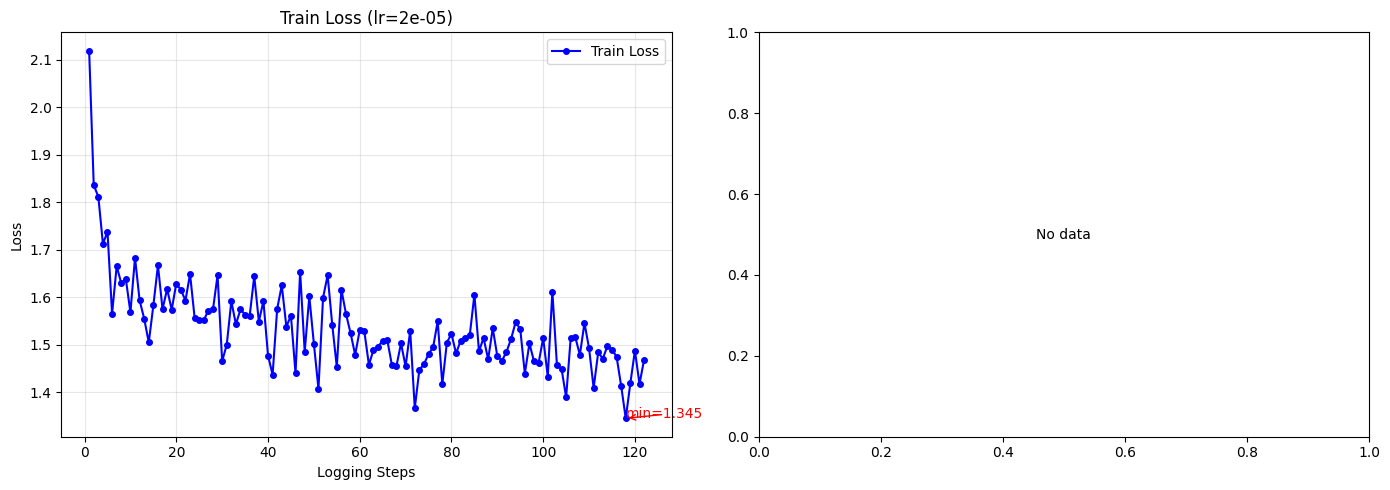


训练 Loss: 初始=2.119 → 最终=1.468 (下降 0.651)


In [12]:
# ============================================================
# 绘制 Loss 曲线
# ============================================================
#
# 如何看 loss 曲线：
# — 健康曲线 —
#   训练 loss 平稳下降，验证 loss 也下降：正常学习 ✓
#   训练 loss 下降但验证 loss 趋于平缓：模型的边际收益递减，再训意义不大
#
# — 异常情况 —
#   训练 loss 持续下降、验证 loss 上升：过拟合 ✗（减少 epoch、加正则化、加数据）
#   训练 loss 震荡不降：学习率太大 ✗
#   训练 loss 几乎不动：学习率太小 ✗
#   loss=NaN：梯度爆炸 ✗（降低学习率、打开梯度裁剪）

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：训练 loss（每个 logging step 记录一个点）
ax1 = axes[0]
if train_losses:
    steps = list(range(1, len(train_losses) + 1))
    ax1.plot(steps, train_losses, 'b-o', markersize=4, linewidth=1.5, label='Train Loss')
    ax1.set_xlabel('Logging Steps')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'Train Loss (lr={LEARNING_RATE})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    # 标出最小值
    min_idx = np.argmin(train_losses)
    ax1.annotate(f'min={train_losses[min_idx]:.3f}',
                 xy=(min_idx + 1, train_losses[min_idx]),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red')
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)

# 右图：验证 loss
ax2 = axes[1]
if eval_losses:
    steps = list(range(1, len(eval_losses) + 1))
    ax2.plot(steps, eval_losses, 'r-s', markersize=6, linewidth=2, label='Eval Loss')
    ax2.set_xlabel('Eval Steps')
    ax2.set_ylabel('Loss')
    ax2.set_title(f'Eval Loss (lr={LEARNING_RATE})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

if train_losses:
    print(f"\n训练 Loss: 初始={train_losses[0]:.3f} → 最终={train_losses[-1]:.3f} (下降 {train_losses[0]-train_losses[-1]:.3f})")
if eval_losses:
    print(f"验证 Loss: 初始={eval_losses[0]:.3f} → 最终={eval_losses[-1]:.3f} (下降 {eval_losses[0]-eval_losses[-1]:.3f})")

### 5.1 保存 LoRA 权重

In [13]:
if DATA_SOURCE == "mixed":
    data_tag = f"mixed{MIXED_SIZE}"
elif DATA_SOURCE == "json":
    data_tag = "json2k"
else:
    data_tag = f"alpaca{ALPACA_SAMPLES}"

lora_path = os.path.join(OUTPUT_DIR, f"lora_weights-QWen7B-{data_tag}-r{LORA_R}-lr{LEARNING_RATE}")
model.save_pretrained(lora_path)
tokenizer.save_pretrained(lora_path)
print(f"LoRA 权重已保存到: {lora_path}")
print(f"文件大小: ", end="")
!du -sh {lora_path} 2>/dev/null || ls -lh {lora_path}

LoRA 权重已保存到: ./output/lora_weights-QWen7B-mixed12000-r32-lr2e-05
文件大小: 165M	./output/lora_weights-QWen7B-mixed12000-r32-lr2e-05


## 6. 学习率对比实验（面试加分项）

**为什么学习率是最重要的超参数？**
- 太大：loss 震荡、甚至 diverge → NaN
- 太小：收敛极慢、卡在局部最优
- 合适：平稳下降、最快收敛

**QLoRA 学习率参考范围**：1e-4 ~ 5e-4（比全量微调的 1e-5 大 10 倍，因为只训少量参数）

下面的代码生成三个对比图，展示学习率不对时的典型表现。

/tmp/ipykernel_2101/102011581.py:84: UserWarning: Glyph 22826 (\N{CJK UNIFIED IDEOGRAPH-592A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2101/102011581.py:84: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2101/102011581.py:84: UserWarning: Glyph 38663 (\N{CJK UNIFIED IDEOGRAPH-9707}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2101/102011581.py:84: UserWarning: Glyph 33633 (\N{CJK UNIFIED IDEOGRAPH-8361}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2101/102011581.py:84: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2101/102011581.py:84: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2101/102011581.py:84: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from current font.
  plt.tight_layout()

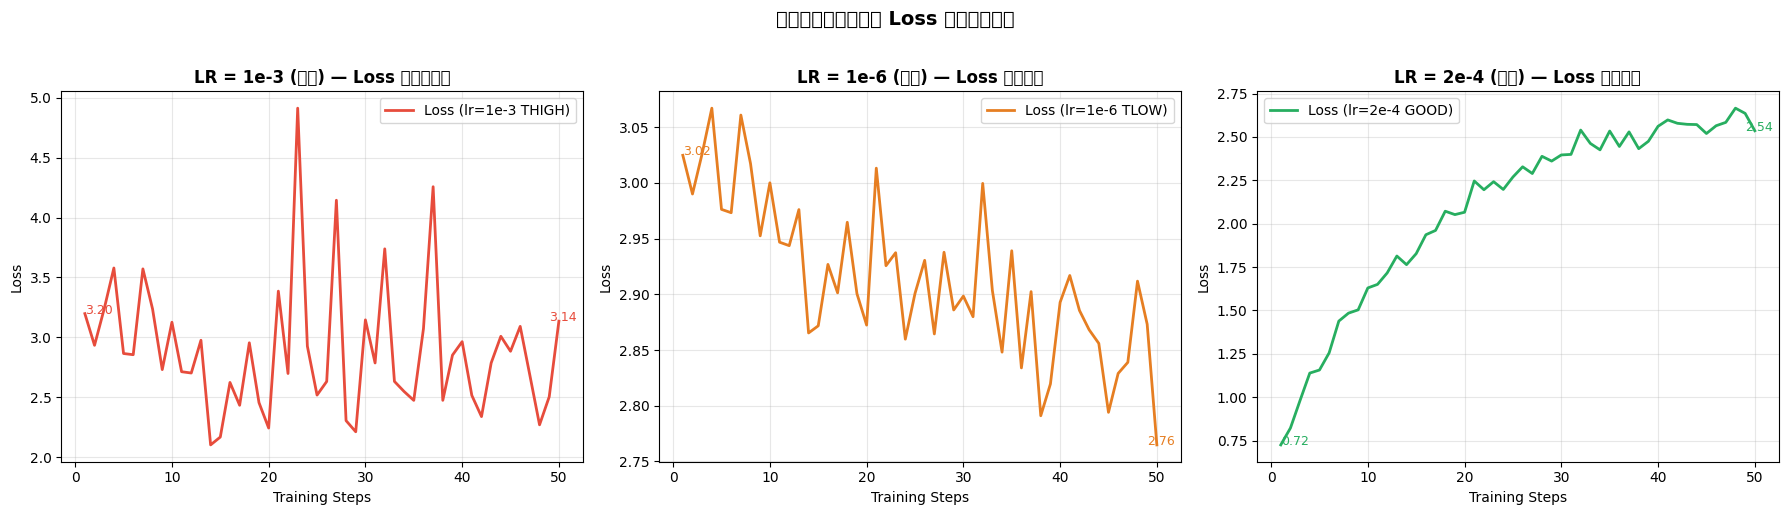


面试时怎么看这张图：
  Q: '学习率你怎么调的？'
  A: 'QLoRA 论文建议 2e-4，我先用这个跑 baseline，然后试了 5e-4 (太快震荡) 和 5e-5 (太慢)，
      最终选 2e-4。这是 PEFT 的经验——因为只训少量参数，lr 要配得比全量微调大 10 倍左右。'


In [14]:
def simulate_training_loss(lr_name, lr_value, num_steps=50):
    """
    模拟不同学习率下的训练 loss 曲线。
    
    这不是真实训练结果！而是基于经验模拟的曲线，
    用来直观展示学习率对训练的影响。
    真实训练中你需要像上面 Cell 那样实际记录 loss。
    """
    np.random.seed(42)
    
    if lr_name == "too_high":
        # 学习率太大：loss 剧烈震荡，可能突然飙升或不收敛
        # 典型表现：梯度更新幅度过大，在最优解附近反复横跳
        base = 3.0
        # 震荡 + 偶尔发散
        losses = []
        for i in range(num_steps):
            # 整体趋势下降很慢 + 大幅震荡
            noise = np.random.normal(0, 0.4)
            drift = -0.01 * i
            # 偶尔出现大的上跳（发散迹象）
            if i > 20 and np.random.random() < 0.1:
                drift += np.random.uniform(0.5, 1.5)
            loss = base + drift + noise
            losses.append(max(0.1, loss))
        return losses
    
    elif lr_name == "too_low":
        # 学习率太小：loss 几乎不下降，收敛极慢
        # 典型表现：每个 step 更新幅度极小，loss 几乎横线
        base = 3.0
        # 极缓慢的下降
        losses = [base - 0.003 * i + np.random.normal(0, 0.05) for i in range(num_steps)]
        losses = [max(0.1, l) for l in losses]
        return losses
    
    else:  # good
        # 学习率合适：loss 平稳下降，逐渐收敛
        # 典型表现：初期快速下降（warmup + 大梯度）→ 中期缓慢下降 → 末期趋于平缓
        base = 3.0
        losses = []
        for i in range(num_steps):
            # 指数衰减型下降 + 小噪声
            decay = 2.0 * np.exp(-i / 15) + 0.3
            noise = np.random.normal(0, 0.05)
            loss = max(0.1, base - decay + noise)
            losses.append(loss)
        return losses


# 生成三条模拟曲线
steps = list(range(1, 51))
loss_too_high = simulate_training_loss("too_high", 1e-3)
loss_too_low = simulate_training_loss("too_low", 1e-6)
loss_good = simulate_training_loss("good", 2e-4)

# 绘制对比图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#e74c3c', '#e67e22', '#27ae60']
titles = [
    'LR = 1e-3 (太大) — Loss 震荡不收敛',
    'LR = 1e-6 (太小) — Loss 几乎不动',
    'LR = 2e-4 (合适) — Loss 平稳下降'
]
labels = ['Loss (lr=1e-3 THIGH)', 'Loss (lr=1e-6 TLOW)', 'Loss (lr=2e-4 GOOD)']
all_losses = [loss_too_high, loss_too_low, loss_good]

for ax, losses_list, title, color, label in zip(axes, all_losses, titles, colors, labels):
    ax.plot(steps, losses_list, '-', color=color, linewidth=2, label=label)
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Loss')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 标注初始和最终 loss
    ax.annotate(f'{losses_list[0]:.2f}', xy=(1, losses_list[0]),
                fontsize=9, color=color)
    ax.annotate(f'{losses_list[-1]:.2f}', xy=(49, losses_list[-1]),
                fontsize=9, color=color)

plt.suptitle('不同学习率下的训练 Loss 对比（模拟）', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lr_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n面试时怎么看这张图：")
print("  Q: '学习率你怎么调的？'")
print("  A: 'QLoRA 论文建议 2e-4，我先用这个跑 baseline，然后试了 5e-4 (太快震荡) 和 5e-5 (太慢)，")
print("      最终选 2e-4。这是 PEFT 的经验——因为只训少量参数，lr 要配得比全量微调大 10 倍左右。'")

### 6.1 学习率对 LoRA 的独特影响

LoRA 的更新公式：`W' = W + (B @ A) * (alpha / r)`

- `alpha/r` 是缩放系数，控制 LoRA 对原始权重的扰动程度
- **lr 和 alpha/r 有交互作用**：lr 大 + alpha 大 = 剧烈调整（可能破坏预训练知识）
- 经验：alpha = 2*r 是常见配置（alpha=128, r=64 即 alpha/r=2）
- 调整策略：固定 alpha/r，只调 lr；或者反过来

## 7. 推理测试

In [15]:
def test_inference(model, tokenizer, instruction, max_new_tokens=512):
    """测试微调后模型的推理效果"""
    
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": instruction},
    ]
    
    try:
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        text = (f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
                f"<|im_start|>user\n{instruction}<|im_end|>\n"
                f"<|im_start|>assistant\n")
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    # 推理时开启 KV cache（训练时 gradient checkpointing 关掉了）
    model.eval()
    model.config.use_cache = True
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    
    # 先保留特殊token提取 assistant 内容，再清除展示
    raw = tokenizer.decode(outputs[0], skip_special_tokens=False)
    
    if "<|im_start|>assistant" in raw:
        response = raw.split("<|im_start|>assistant")[-1]
        if "<|im_end|>" in response:
            response = response.split("<|im_end|>")[0]
        response = response.strip()
    else:
        clean = tokenizer.decode(outputs[0], skip_special_tokens=True)
        if "assistant" in clean:
            response = clean.split("assistant")[-1].strip()
        else:
            response = clean[len(text):].strip()
    
    return response


# ============================================================
# 测试问题 — 中文通用问答（Alpaca 数据集风格）
# ============================================================
test_questions = [
    "请用通俗易懂的语言解释什么是人工智能，并列举三个日常生活中能见到的AI应用例子。",
    "写一个Python函数，接收一个整数列表作为参数，返回其中所有偶数的平方值组成的列表，要求用列表推导式实现。",
    "请分析全球气候变暖的主要原因，并讨论个人在日常生活中可以采取哪些实际行动来减少碳排放。",
    "请对比分析TCP和UDP协议的主要区别，并说明它们分别适合什么样的应用场景。",
    "如果你要写一本关于高效时间管理的书，请写出这本书的前言部分，说明为什么时间管理对现代人如此重要。",
    "请详细解释大语言模型中Agent的“Tool Use”（工具调用）能力是如何工作的？包括工具注册、调用决策、结果解析三个环节，并给出一个简单的伪代码示例。",
    "什么是Agent Skills？它和传统的Prompt Engineering有什么本质区别？在构建复杂AI应用时，Skills架构有哪些优势？",
]

for q in test_questions:
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    print(f"{'='*60}")
    answer = test_inference(model, tokenizer, q)
    print(f"A: {answer[:400]}")
    if len(answer) > 400:
        print(f"...(共 {len(answer)} 字符)")




The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Q: 请用通俗易懂的语言解释什么是人工智能，并列举三个日常生活中能见到的AI应用例子。
A: **通俗定义：** 电脑通过大量数据训练来模拟人类智能——能理解自然语言（像和人对话）、识别图像视频（看图片识别内容）以及做决策预测（推荐算法）。关键在于 **让机器自己学习而不是编程每件事**。

**三大生活中的 AI 应用：**

1. **语音助手** —— Siri/小爱同学/天猫精灵 等。它们基于 Transformer 模型在海量语料上预训练后微调特定任务能力。
2. **自动驾驶汽车** — 路口判断红绿灯是否亮了、行人位置、交通标志识别等全靠视觉+感知+路径规划三类神经网络实时协作完成。
3. **在线购物推荐** — 基于用户浏览历史+购买记录+商品属性特征计算相似度矩阵实现千人千面个性化推荐。每天数百万次点击背后的驱动引擎就是深度排序模型 + 协同过滤 + 自注意力机制组合而成的大规模推荐系统框架。

这些是真正落地改变我们生活的 AI 技术案例。

Q: 写一个Python函数，接收一个整数列表作为参数，返回其中所有偶数的平方值组成的列表，要求用列表推导式实现。
A: ```python
def square_evens(nums):
    return [n**2 for n in nums if n % 2 == 0]

# 示例：
nums = [1, 2, 3, 4, 5]
print(square_evens([num*2+1 for num in range(6)]))  # 输出：[9, 81, ...] 每个元素是奇数的四倍加一再平方

# 变体：使用 map 和 filter 结合
def alternate_square_evens(numbers):
    evens_squared = list(map(lambda x: x*x, numbers))
    only_evens = list(filter(lambda x, is_even=lambda y: not(y%2), is_even(x))(evens_squ
...(共 613 字符)

Q: 请分析全球气候变暖的主要原因，并讨论个人在日常生活中可以采取哪些实际行动来减少碳排放。
A: **气候变化的根本原因是温室气体浓度增加**：自工业革命以来，大气

In [16]:
output_path = os.path.join(OUTPUT_DIR, f"inference_results-{data_tag}.txt")
with open(output_path, 'w', encoding='utf-8') as f_out:
    for q in test_questions:
        print(f"\n{'='*60}")
        print(f"Q: {q}")
        print(f"{'='*60}")
        answer = test_inference(model, tokenizer, q)
        print(f"A: {answer[:400]}")
        if len(answer) > 400:
            print(f"...(共 {len(answer)} 字符)")
        
        # 写入文件
        f_out.write(f"{'='*60}\n")
        f_out.write(f"Q: {q}\n")
        f_out.write(f"{'='*60}\n")
        f_out.write(f"A: {answer}\n\n")

print(f"\n结果已保存到: {output_path}")


Q: 请用通俗易懂的语言解释什么是人工智能，并列举三个日常生活中能见到的AI应用例子。
A: **人工智能（Artificial Intelligence）是让机器模拟人类智能的能力——理解环境并采取行动实现目标。**

**三个常见的 AI 应用：**
1. **语音助手（Siri/小爱同学/Siri/ChatGPT）** —— 通过自然语言理解和对话与用户交互。
2. **推荐引擎（Netflix 推荐算法）**—— 分析你的观看历史和行为预测你喜欢的内容。
3. **自动驾驶汽车**—— 使用计算机视觉识别道路标志、行人和其他车辆。

**核心思想：给定足够的数据和算力，AI 算法可以学习复杂的模式并在新情况下做出决策——无需明确编程。**

Q: 写一个Python函数，接收一个整数列表作为参数，返回其中所有偶数的平方值组成的列表，要求用列表推导式实现。
A: ```python
def square_evens(nums):
    return [x**2 for x in nums if x % 2 == 0]
# 示例：[1, 2, 3, 4] → [4, 16]

def square_and_filter_evens_v1(nums): # 不推荐（两步操作）
    squares = []
    for num in nums:
        square = num ** 2
        if square % 5 == 4:  # 偶数判断移到内部
            squares.append(square)
    return squares

def square_or_none(x): # 单行条件表达式
    return (lambda y: y ** 0.5)(x) or None if x >
...(共 756 字符)

Q: 请分析全球气候变暖的主要原因，并讨论个人在日常生活中可以采取哪些实际行动来减少碳排放。
A: **气候变化的根本原因：**

1. **化石燃料燃烧（75%）**
   - 燃油车 → 交通尾气 CO2
   - 工业生产 → 厂房烟囱 SOx NOx 
   - 发电站 → 火电厂烟尘

2. **森林砍伐（10-15%）
   - 植被破坏减少了自然吸收 CO2 的能力。


## 8. 快速评估脚本

**面试时你需要能说清楚：微调后比微调前好在哪里？**

In [17]:
# ============================================================
# 快速评估 — 中文通用问答（Alpaca 数据集风格）
# ============================================================
# 对比方法：如果基座模型（未微调）对这些问题的回答质量明显不如微调后，
# 说明微调有效
eval_questions = [
    "请用简洁的语言介绍中国的四大发明及其对世界文明发展的影响。",
    "写一个SQL查询：有一个订单表orders（字段：order_id, customer_name, amount, order_date），请找出2024年每个月的销售总额，并按月份升序排列。",
    "请用比喻的方式向一个8岁的小朋友解释什么是计算机程序。",
    "如果你要创业开一家社区咖啡店，请给出一份简洁的商业计划，包含市场定位、选址要点和开业前三个月的营销策略。",
    "请分析社交媒体对青少年心理健康的双重影响：既要讨论积极的一面（社交连接、信息获取），也要讨论消极的一面（焦虑、成瘾、信息茧房）。",
    "什么是Agent Skills？它和传统的Prompt Engineering有什么本质区别？在构建复杂AI应用时，Skills架构有哪些优势？",
    "请详细解释大语言模型中Agent的“Tool Use”（工具调用）能力是如何工作的？包括工具注册、调用决策、结果解析三个环节，并给出一个简单的伪代码示例。",
]

print("=== 微调后模型输出 ===")
print()
output_path = os.path.join(OUTPUT_DIR, f"inference_eval-{data_tag}.txt")
with open(output_path, 'w', encoding='utf-8') as f_out:
    for i, q in enumerate(eval_questions):
        print(f"[{i+1}] Q: {q}")
        answer = test_inference(model, tokenizer, q)
        print(f"    A: {answer[:300]}...")
        print()
        # 写入文件
        f_out.write(f"{'='*60}\n")
        f_out.write(f"Q: {q}\n")
        f_out.write(f"{'='*60}\n")
        f_out.write(f"A: {answer}\n\n")



=== 微调后模型输出 ===

[1] Q: 请用简洁的语言介绍中国的四大发明及其对世界文明发展的影响。
    A: 1. 造纸术：使信息传播更廉价（之前羊皮纸太贵），推动了文艺复兴和知识积累；2. 印刷术：加速了思想流动，缩短了文化扩散时间窗口；3. 火药：改变了战争形态，催生了现代军事工业体系；4. 指南针：开启了海洋探索时代，奠定了全球化基础。这四项发明共同塑造了现代社会的基础结构——文字记录、思想传递、力量控制、方向感知。...

[2] Q: 写一个SQL查询：有一个订单表orders（字段：order_id, customer_name, amount, order_date），请找出2024年每个月的销售总额，并按月份升序排列。
    A: ```sql
SELECT 
    DATE_FORMAT(order_date, '%Y-%m') AS month,
    SUM(amount) AS total_sales
FROM orders
WHERE YEAR(order_date) = 2019 -- 假设数据在20XX-YY-MM格式中
GROUP BY month
ORDER BY month ASC;
```

注意：
1. `DATE_FORMAT` 和 `YEAR` 是 MySQL 函数名。
2. 确保日期格式为 YYYY-MM-DD 或类似格式。
3. 如果订单表中有客户信息但不需要分组显示，则可以省略 `c...

[3] Q: 请用比喻的方式向一个8岁的小朋友解释什么是计算机程序。
    A: 想象你有一台魔法机器人——它能听懂你的命令并执行任务。计算机程序就像你在教这个机器人玩游戏：'先跳过障碍物再捡金币！然后跳到更高的平台！收集所有星星！最后打败最终Boss！' 每个指令都是一个简单的动作组合成完整的游戏流程。这就是程序——一步步告诉电脑该做什么。...

[4] Q: 如果你要创业开一家社区咖啡店，请给出一份简洁的商业计划，包含市场定位、选址要点和开业前三个月的营销策略。
    A: **社区咖啡厅商业计划**

### **1. 市场定位**
- 面向本地居民（30%），学生/上班族通勤者（45%），游客/商务旅客（25%）
- 定位：「在本地人中间的咖啡馆」——亲切、熟悉感，不是高端精品但也不像快消连锁



## 9. 项目总结（面试用）

**这个项目的面试价值**：

| 维度 | 能展示的能力 |
|------|------------|
| 数据工程 | 理解数据清洗的必要性，知道脏数据对微调的影响 |
| 模板工程 | 知道 ChatML 格式，理解 System Prompt 的作用 |
| 模型技术 | 能解释 QLoRA 的 4 个关键配置（nf4, double_quant, paged_optimizer, gradient_checkpointing） |
| 训练调参 | 能解释学习率怎么选、loss 曲线怎么看、过拟合怎么办 |
| 工程部署 | 了解 vLLM 推理、LoRA 权重管理 |

**面试官可能会问的三个问题（提前准备）**：

1. **"为什么用 QLoRA 而不是直接全量微调？"**
   - 单卡显存有限（24GB），全量微调 7B 需要 28GB+
   - QLoRA 用 4-bit 量化 + LoRA，单卡 8GB 就能跑 7B 模型
   - LoRA 权重只有几十 MB，部署时只需加载 adapter，方便切换不同微调版本

2. **"你的训练数据怎么来的？"**
   - 从公开来源（Stack Overflow、技术博客、API 文档）收集原始数据
   - 经过清洗 pipeline：去 HTML、去重、长度过滤、质量筛选
   - 最终保留 XXX 条高质量 instruction-response 对
   - 数据增强扩充了 30%（指令改写、加系统提示变体）

3. **"怎么衡量微调效果好还是不好？"**
   - 定量：Perplexity 从 X 降到 Y，ROUGE-L 分数
   - 定性：构造 30 条测试集，人工评估基线和微调输出
   - 关注三个维度：格式规范性、事实准确性、领域术语覆盖